In [2]:
import sys
import os
from pathlib import Path

if 'google.colab' in sys.modules:
    print("Ambiente Colab rilevato. Inizializzazione in corso...")
    
    # 1. Monta Drive (se non già montato)
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
        
    # Imposta la root del Drive su Colab
    BASE_DIR = Path('/content/drive/Shareddrives/Progetti/Progetto_MLDM')

    GIT_BRANCH = 'feature-importance'
    
    # 2. Clona/Aggiorna la repo
    REPO_DIR = '/content/crop-spatial-classification'
    if not os.path.exists(REPO_DIR):
        !git clone -b {GIT_BRANCH} https://github.com/SimoRinaldi/crop-spatial-classification.git {REPO_DIR}
    else:
        !cd {REPO_DIR} && git fetch origin && git checkout -B {GIT_BRANCH} origin/{GIT_BRANCH} && git reset --hard origin/{GIT_BRANCH} && git clean -fd
    
    # 3. Aggancia la cartella per permettere gli import
    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)
        
    # 4. Installa i requisiti in modo silenzioso
    %pip install -q -r {REPO_DIR}/requirements.txt
    print("Setup ambiente Colab completato! Branch attivo su Colab: ", GIT_BRANCH)
    
else:
    print("Ambiente Locale rilevato. Procedo con l'esecuzione...")
    
    BASE_DIR = Path.cwd().parent

    if str(BASE_DIR) not in sys.path:
        sys.path.append(str(BASE_DIR))

# =============================
# DEFINIZIONE PATH UNIVERSALI
# =============================
DATA_DIR = BASE_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
INTERIM_DIR = DATA_DIR / 'interim'
PROCESSED_DIR = DATA_DIR / 'processed'

# Test di verifica per assicurarsi che i dati siano accessibili
if RAW_DIR.exists():
    print(f"✅ Collegamento ai dati riuscito! Cartella raw: {RAW_DIR}")
else:
    print(f"❌ Attenzione: Cartella non trovata in {RAW_DIR}. Verifica il nome, il mount o il path locale.")

Ambiente Colab rilevato. Inizializzazione in corso...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 24 (delta 14), reused 21 (delta 11), pack-reused 0 (from 0)
Unpacking objects: 100% (24/24), 11.72 KiB | 333.00 KiB/s, done.
From https://github.com/SimoRinaldi/crop-spatial-classification
 * [new branch]      incremento-punti-dataset -> origin/incremento-punti-dataset
branch 'test-ricerca-iperparametri' set up to track 'origin/test-ricerca-iperparametri'.
Reset branch 'test-ricerca-iperparametri'
Your branch is up to date with 'origin/test-ricerca-iperparametri'.
HEAD is now at 79fc382 test 1 - ricerca iperparametri
Setup ambiente Colab completato! Branch attivo su Colab:  test-ricerca-iperparametri
✅ Collegamento ai dati riuscito! Cartella raw: /content/drive/MyDrive/Progetto MLDM/data/raw


# 04 - Addestramento Random Forest e valutazione delle prestazioni
- Addestramento del modello Random Forest su serie temporali spettrali Sentinel-2
- Valutazione su 15 classi e su 4 macro-classi agronomiche
- Analisi degli errori tramite matrice di confusione normalizzata e feature importance

#### Caricamento del dataset e selezione delle feature predittive

In [3]:
import json
import pandas as pd
from pathlib import Path

# percorsi dei file generati nel notebook 03
dataset_path = PROCESSED_DIR / 'dataset' / 'dataset.parquet'
legend_path = PROCESSED_DIR / 'legend.json'

# caricamento del dataset
dataset = pd.read_parquet(dataset_path)

# esclusione dei metadati dalla lista delle feature
non_features = ["ID_Campo", "Year", "Ground_Truth", "Crop_Name"]
features = [f for f in dataset.columns if f not in non_features]

X = dataset[features]
y = dataset["Ground_Truth"].astype(int)

# caricamento legenda delle colture
legend = {}
if legend_path.exists():
    with open(legend_path, "r", encoding="utf-8") as f:
        legend = json.load(f)

print(f"Dataset caricato con successo:")
print(f"  • Campioni totali: {X.shape[0]}")
print(f"  • Features: {X.shape[1]}")
print(f"  • Classi distinte: {y.nunique()}")

Dataset caricato con successo:
  • Campioni totali: 4507
  • Features: 51
  • Classi distinte: 15


#### Suddivisione train e test

In [4]:
from sklearn.model_selection import train_test_split

test_size = 0.30

# suddivisione 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=y
)

print(f"Dataset suddiviso:")
print(f"  • Set di addestramento (train - {(1-test_size) * 100}%): {X_train.shape[0]} esempi")
print(f"  • Set di test (test - {test_size * 100}%): {X_test.shape[0]} esempi")

Dataset suddiviso:
  • Set di addestramento (train - 70.0%): 3154 esempi
  • Set di test (test - 30.0%): 1353 esempi


#### Ricerca iperparametri

In [8]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# inizializzazione base
model = RandomForestClassifier(
    random_state=42,
    max_features='sqrt'
)

# definizione del param_grid per il GridSearchCV()
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2],
    'class_weight': ['balanced_subsample'],
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy', # provare 'f1_macro' per favorire la predizione delle colture minori
    cv=5,
    n_jobs=-1,
    verbose=10
)

print("Inizio addestramento del modello...")
start_time = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"Addestramento completato in {elapsed:.2f} secondi.")

# estrae i risultati migliori
print("Migliori parametri:", grid_search.best_params_)

Inizio addestramento del modello...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Addestramento completato in 563.82 secondi.
Migliori parametri: {'class_weight': 'balanced_subsample', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Punteggio medio ottenuto:  0.6499574874852212
Predizione sul test set:  [1410 2310 2100 ... 2200 1220 1120]


#### Addestramento del modello Random Forest

In [5]:
import time
from sklearn.ensemble import RandomForestClassifier

prediction = grid_search.predict(X_test)
print("Predizione sul test set: ", prediction)

Inizio addestramento del modello...
Addestramento completato in 12.36 secondi.


#### Valutazione delle prestazioni

In [6]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# nomi leggibili ordinati per le classi presenti nel set di test
unique_classes = sorted(y_test.unique())
target_names = [f"{legend.get(str(c), c)} ({c})" for c in unique_classes]

print("Classification Report")
print("=" * 65)
print(classification_report(y_test, prediction, target_names=target_names, digits=3, zero_division=0))

acc_score = accuracy_score(y_test, prediction)
macro_f1 = f1_score(y_test, prediction, average="macro")
print(f"Metriche globali:")
print(f"  • Accuracy globale: {acc_score * 100:.2f}%")
print(f"  • Macro F1-Score:   {macro_f1 * 100:.2f}%")

Classification Report
                             precision    recall  f1-score   support

               Wheat (1110)      0.545     0.625     0.583        96
              Barley (1120)      0.542     0.469     0.503        96
               Maize (1130)      0.691     0.691     0.691        81
                Rice (1140)      1.000     0.972     0.986        72
    Fresh Vegetables (1210)      0.449     0.229     0.303        96
          Dry Pulses (1220)      0.592     0.469     0.523        96
            Potatoes (1310)      0.656     0.615     0.634        96
           Sunflower (1410)      0.710     0.688     0.698        96
            Soybeans (1420)      0.851     0.833     0.842        48
            Rapeseed (1430)      0.629     0.635     0.632        96
Flax cotton and hemp (1440)      0.686     0.729     0.707        96
              Grapes (2100)      0.673     0.771     0.718        96
              Olives (2200)      0.575     0.719     0.639        96
           

#### Valutazione gerarchica sulle macro-classi agronomiche

In [7]:
# mappatura delle 15 classi dettagliate in 4 macro-classi agronomiche
def map_to_macro(code):
    c = int(code)
    if c in [1110, 1120, 1130, 1140]:
        return "Cereali"
    elif c in [1210, 1220, 1310]:
        return "Ortive, Legumi e Tuberi"
    elif c in [1410, 1420, 1430, 1440]:
        return "Oleaginose e Industriali"
    elif c in [2100, 2200, 2310, 2320]:
        return "Legnose e Arboree"
    return "Altro"

# conversione di etichette reali e predette a livello macro
y_test_macro = [map_to_macro(c) for c in y_test]
pred_macro = [map_to_macro(c) for c in prediction]

print("Classification Report")
print("=" * 65)
print(classification_report(y_test_macro, pred_macro, digits=3, zero_division=0))

acc_macro = accuracy_score(y_test_macro, pred_macro)
macro_f1_macro = f1_score(y_test_macro, pred_macro, average="macro")
print(f"Metriche macro-classi:")
print(f"   • Accuracy macro:   {acc_macro * 100:.2f}%")
print(f"   • Macro F1-Score:   {macro_f1_macro * 100:.2f}%")

Classification Report
                          precision    recall  f1-score   support

                 Cereali      0.811     0.809     0.810       345
       Legnose e Arboree      0.785     0.930     0.851       384
Oleaginose e Industriali      0.770     0.777     0.773       336
 Ortive, Legumi e Tuberi      0.758     0.566     0.648       288

                accuracy                          0.783      1353
               macro avg      0.781     0.770     0.771      1353
            weighted avg      0.782     0.783     0.778      1353

Metriche macro-classi:
   • Accuracy macro:   78.34%
   • Macro F1-Score:   77.06%


#### Confusion Matrix

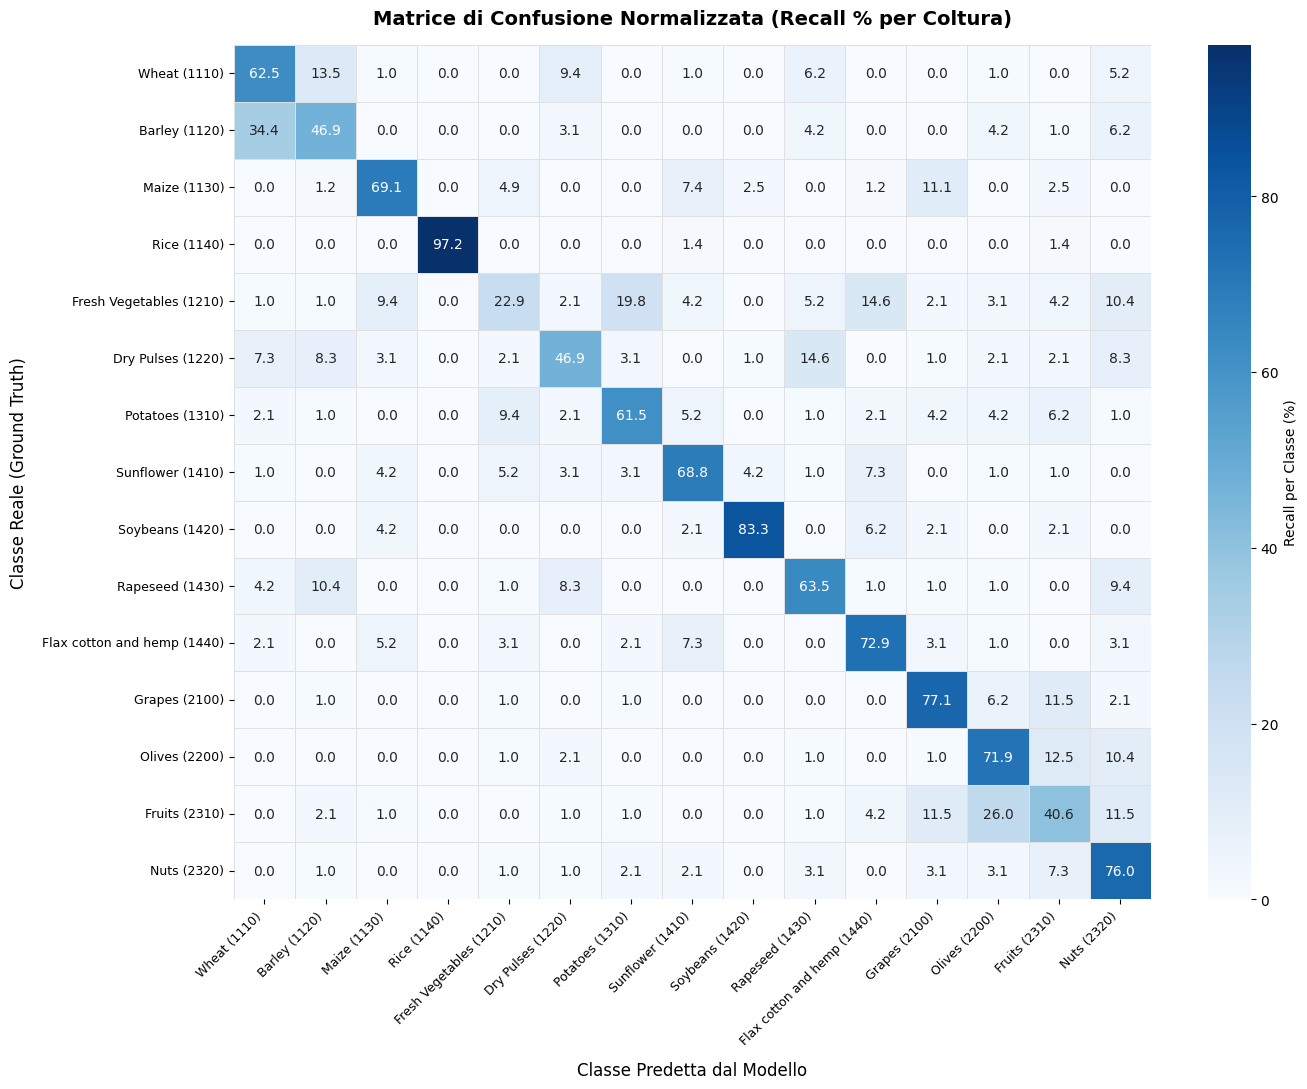

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# calcolo della matrice di confusione
classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, prediction, labels=classes)

# normalizzazione per riga (Recall percentuale per ciascuna classe reale)
with np.errstate(all='ignore'):
    cm_norm = np.nan_to_num(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100)

class_labels = [f"{legend.get(str(c), c)} ({c})" for c in classes]

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar_kws={"label": "Recall per Classe (%)"},
    linewidths=0.5,
    linecolor="#e0e0e0"
)

plt.title("Matrice di Confusione Normalizzata (Recall % per Coltura)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Classe Predetta dal Modello", fontsize=12, labelpad=10)
plt.ylabel("Classe Reale (Ground Truth)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

#### Analisi della Feature Importance

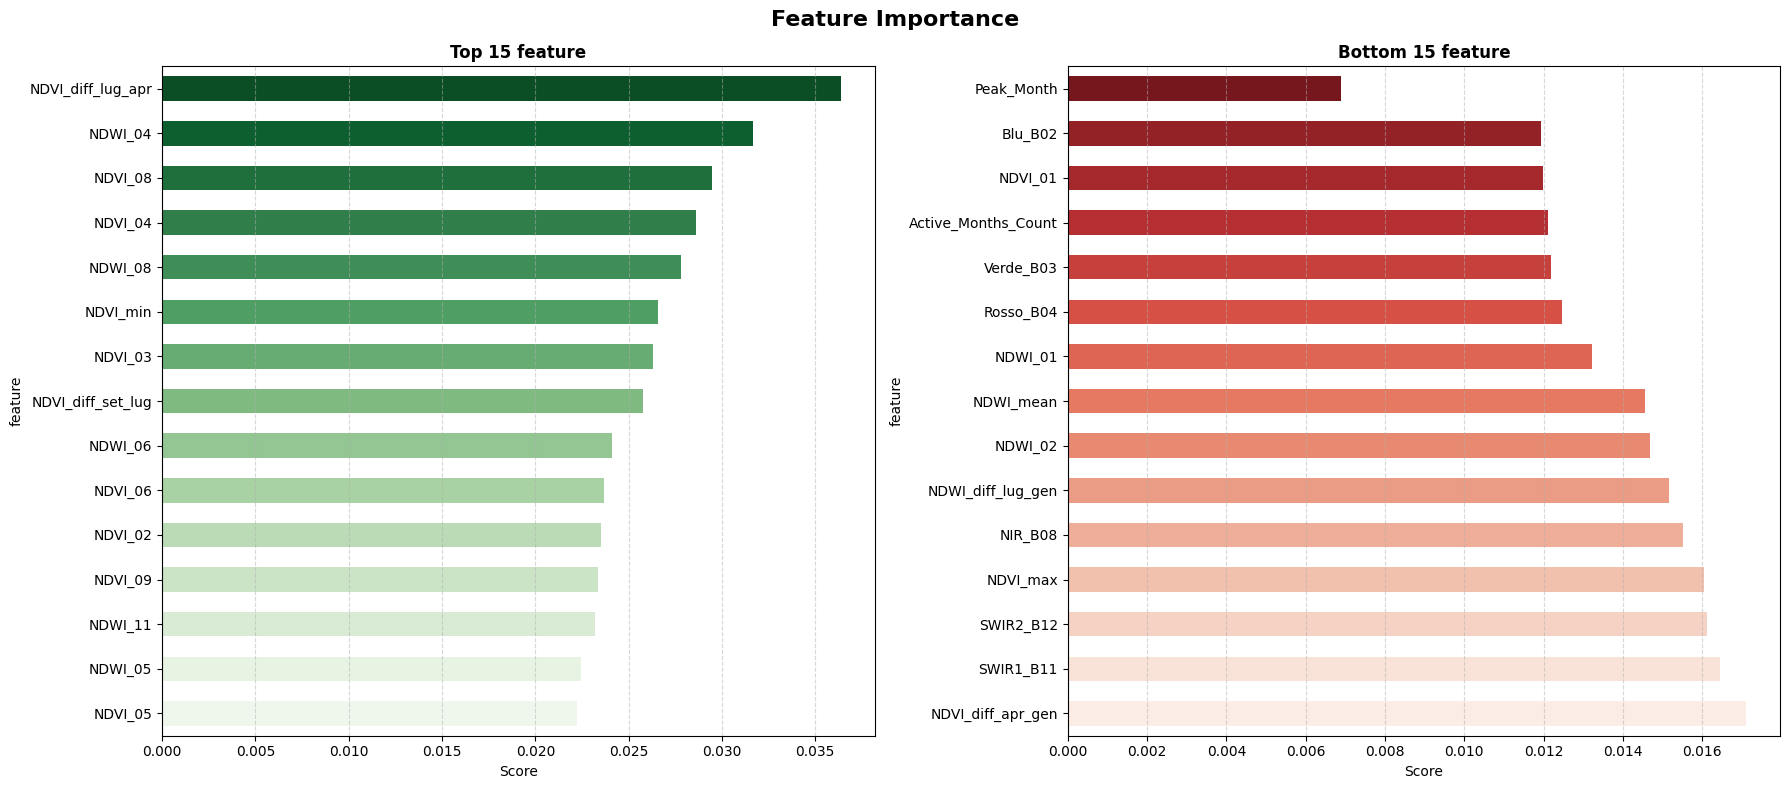

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# creazione del DataFrame ordinato in modo decrescente
feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

N_FEATURES = 15

top_features = feature_importance_df.head(N_FEATURES)
bottom_features = feature_importance_df.tail(N_FEATURES).sort_values(by="importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

fig.suptitle("Feature Importance", fontsize=16, fontweight="bold")

# subplot 1: top features
sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    hue="feature",
    palette="Greens_r",
    width=0.55,
    legend=False,
    ax=axes[0]
)
axes[0].set_title(f"Top {N_FEATURES} feature", fontweight="bold")
axes[0].set_xlabel("Score")
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

# subplot 2: bottom features
sns.barplot(
    data=bottom_features,
    x="importance",
    y="feature",
    hue="feature",
    palette="Reds_r",
    width=0.55,
    legend=False,
    ax=axes[1]
)
axes[1].set_title(f"Bottom {N_FEATURES} feature", fontweight="bold")
axes[1].set_xlabel("Score")
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Salvataggio del modello su disco

In [ ]:
import joblib

# cartella dei modelli salvati
MODELS_DIR = DATA_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "random_forest_crop_model.joblib"

# salvataggio del modello
joblib.dump(model, model_path)
print(f"Modello salvato con successo in: {model_path}")